In [14]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

HERE = Path().resolve()
PROJECT_ROOT = next(p for p in [HERE, *HERE.parents] if (p / "src").exists())
sys.path.insert(0, str(PROJECT_ROOT)) 

from src.io.obd_loader import load_obd_csv, require_columns
from src.io.timebase import add_elapsed_time
from src.physics.kinematics import add_speed_ms, add_acceleration
from src.physics.longitudinal import VehicleParams, add_longitudinal_forces
from src.physics.power_energy import add_power_terms, add_energy_terms
from src.features.efficiency import add_chemical_efficiency

In [18]:
df = load_obd_csv(PROJECT_ROOT/"data/KIT/2017-07-05_Seat_Leon_RT_S_Stau.csv")
require_columns(df, ["time", "speed_kmh", "engine_rpm"])

df = add_elapsed_time(df)
df = add_speed_ms(df)
df = add_acceleration(df)

params = VehicleParams(
    mass_kg=1300, Cd=0.3, area_m2=2.2, crr=0.012,
    tyre_radius_m=0.318, rho_air=1.17
)

df = add_longitudinal_forces(df, params, grade_rad=0.0)
df = add_power_terms(df)
df = add_energy_terms(df)
df = add_chemical_efficiency(df)

print(df)

               time  Engine Coolant Temperature [Â°C]  \
0      07:16:30.444                                31   
1      07:16:30.535                                31   
2      07:16:30.625                                31   
3      07:16:30.716                                31   
4      07:16:30.814                                31   
...             ...                               ...   
46344  08:22:15.439                                91   
46345  08:22:15.524                                91   
46346  08:22:15.615                                91   
46347  08:22:15.704                                91   
46348  08:22:15.794                                91   

       Intake Manifold Absolute Pressure [kPa]  engine_rpm  speed_kmh  \
0                                          NaN         NaN        NaN   
1                                         96.0         NaN        NaN   
2                                         96.0         0.0        NaN   
3                      

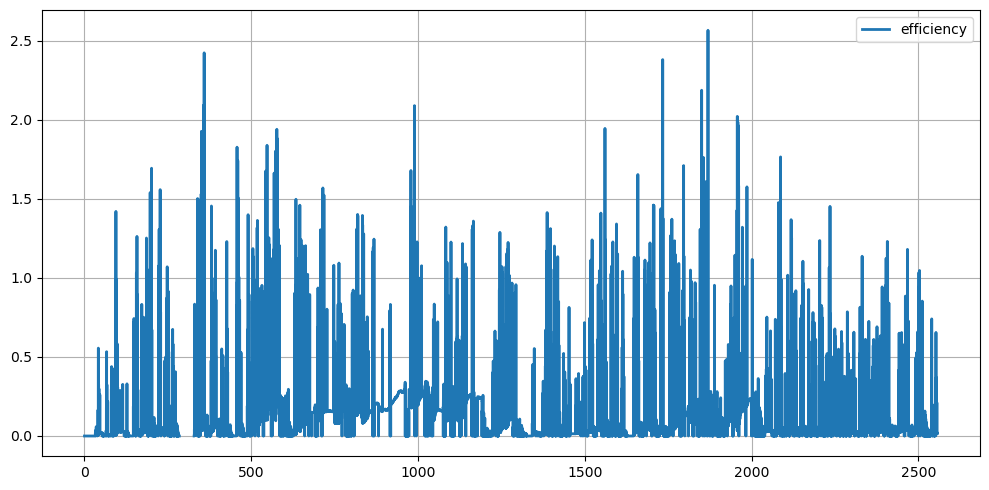

In [19]:
sub = df.iloc[:30000].copy()

plt.figure(figsize=(10,5))
plt.plot(sub["elapsed_time_s"], sub["chemical_efficiency"], label="efficiency", linewidth=2)

plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [20]:
#plt.figure(figsize=(10,5))
#plt.plot(sub["elapsed_time_s"], sub["F_trac_N"], label="efficiency", linewidth=2)

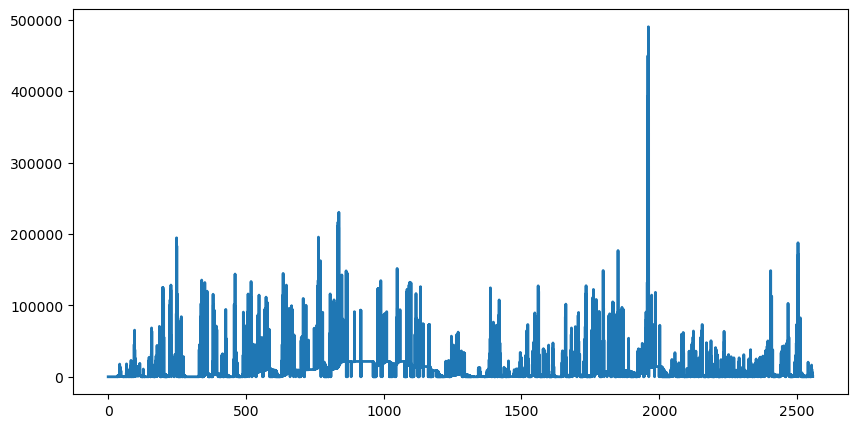

In [5]:
plt.figure(figsize=(10,5))
plt.plot(sub["elapsed_time_s"], sub["P_drive_W"], label="efficiency", linewidth=2)

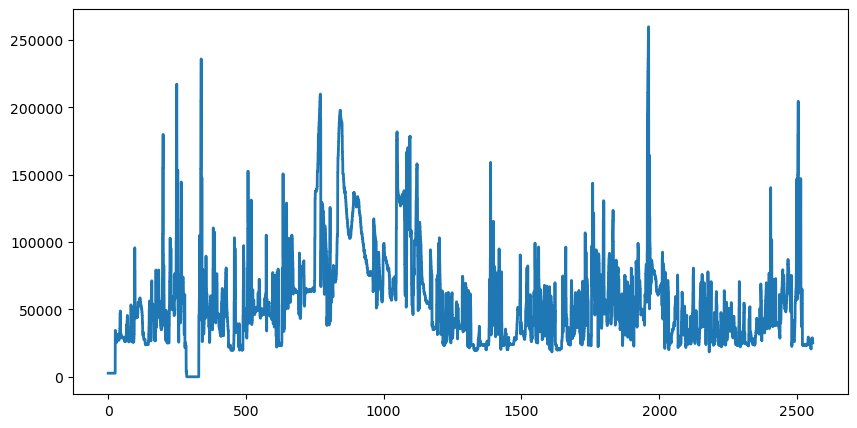

In [13]:
plt.figure(figsize=(10,5))
plt.plot(sub["elapsed_time_s"], sub["Pfuel"], label="efficiency", linewidth=2)

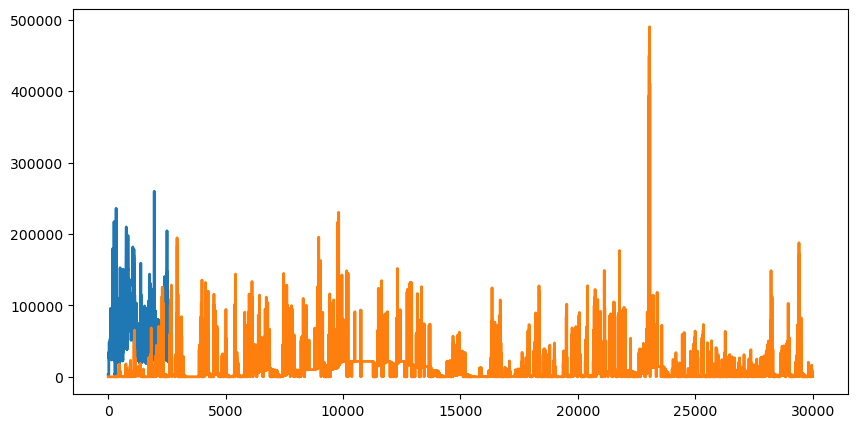

In [10]:
plt.figure(figsize=(10,5))
plt.plot(sub["elapsed_time_s"], sub["Pfuel"], sub["P_drive_W"], label="efficiency", linewidth=2)

In [7]:
result = (df['P_drive_W'] > df['Pfuel']).any()

print(result) 

True


In [8]:
rows_where_true = df[df['P_drive_W'] > df['Pfuel']]
print(rows_where_true)

               time  Engine Coolant Temperature [Â°C]  \
1103   07:18:05.096                                32   
1813   07:19:06.380                                39   
1833   07:19:08.180                                40   
2152   07:19:36.500                                43   
2153   07:19:36.562                                43   
...             ...                               ...   
45413  08:20:58.484                                92   
45442  08:21:01.095                                92   
45443  08:21:01.183                                92   
45632  08:21:17.595                                91   
45633  08:21:17.657                                91   

       Intake Manifold Absolute Pressure [kPa]  engine_rpm  speed_kmh  \
1103                                      99.0      1053.0        9.0   
1813                                     101.0       941.0       16.0   
1833                                     114.0      1410.0       24.0   
2152                   

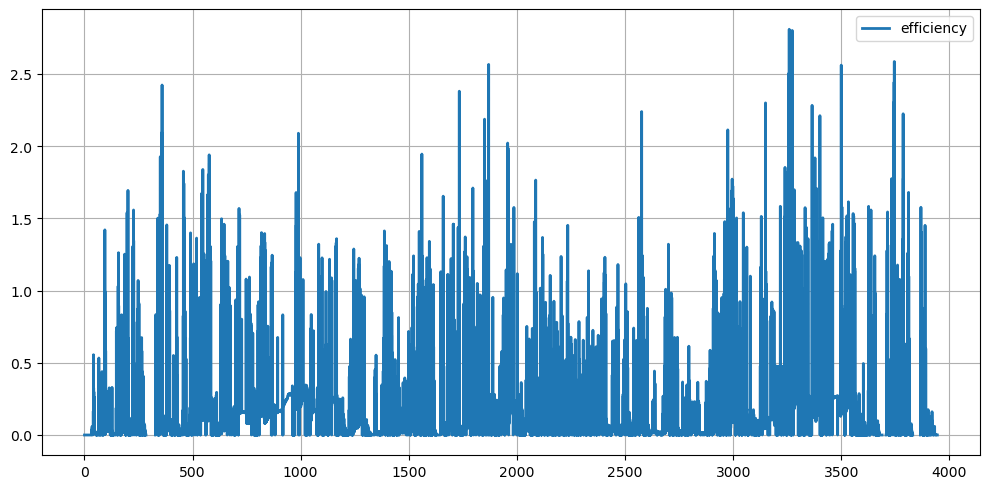

In [11]:
plt.figure(figsize=(10,5))
plt.plot(df["elapsed_time_s"], df["chemical_efficiency"], label="efficiency", linewidth=2)

plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [21]:
rows_where_false = df[df['P_drive_W'] < df['Pfuel']]

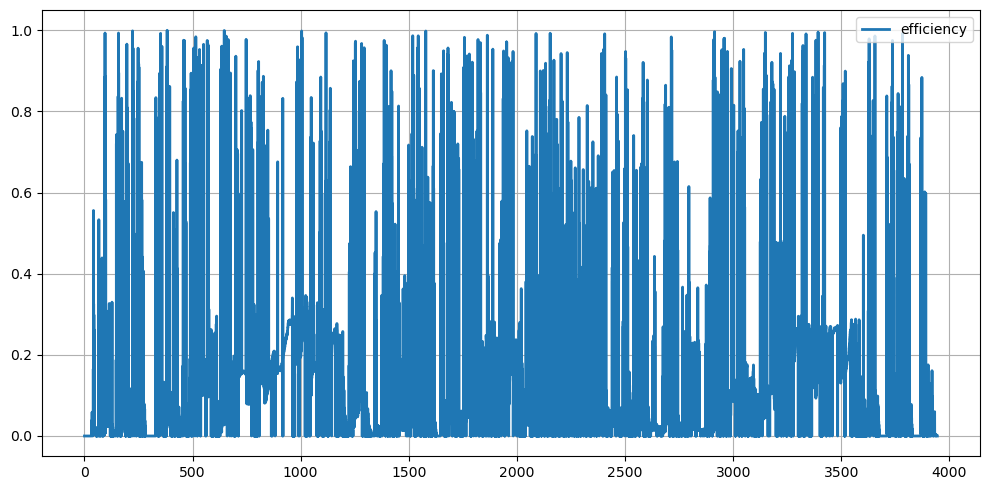

In [22]:
#sub = df.iloc[:30000].copy()

plt.figure(figsize=(10,5))
plt.plot(rows_where_false["elapsed_time_s"], rows_where_false["chemical_efficiency"], label="efficiency", linewidth=2)

plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()